# Mixed-Effects Model: Image Quality as a Predictor of Segmentation Accuracy

Stroke lesion segmentation performance degrades with image quality. This notebook quantifies that relationship by fitting a linear mixed-effects model (LME) relating three image sharpness metrics — FWHM blur (*fwhm\_mm*), high-frequency energy fraction (*hi\_freq\_energy*), and Laplacian variance (*lap\_var*) — to per-subject soft Dice scores produced by the v3 segmentation model.

**Experimental design.** The model is trained on 828 image–Dice pairs drawn from 138 subjects evaluated under six conditions: natural high-resolution acquisition and five synthetic degradations (isotropic crude downsampling, thick axial slices, in-plane coarsening, reduced SNR, and rigid slice jitter). A random intercept per subject (1 | subject) partitions within-subject degradation effects from between-subject variability in baseline lesion complexity. A binary `misalign` covariate separately captures rigid-jitter artifacts, which manifest as geometric misalignment rather than blur. The fitted model is then applied out-of-sample to 198 naturally low-resolution subjects to test whether quality–accuracy relationships learned from synthetic degradations generalise to real acquisition variability.

**Outputs.** Fixed-effect coefficients quantify the Dice penalty per unit of image degradation; out-of-sample calibration metrics (MAE, RMSE, Pearson *r*) assess external validity; a cubic B-spline sensitivity analysis tests the linearity assumption.

## Reference: Image Quality Metrics & Model Terms

### Image quality metrics (computed on each image individually)

| Metric | Full name | Units | Higher value = | Used as predictor |
|---|---|---|---|---|
| `fwhm_mm` | Full Width at Half Maximum (FWHM) of the spatial autocorrelation | mm | **more blurry** (worse) | `z_mf_fwhm_mm` (negative coeff expected) |
| `hi_freq_energy` | High-frequency energy fraction | unitless [0–1] | more high-freq power — in degraded images this reflects **aliasing/ringing** rather than true sharpness | `z_mf_hi_freq_energy` (negative coeff observed) |
| `lap_var` | Variance of the Laplacian | unitless | **sharper edges** (better) | `z_mf_lap_var` (positive coeff expected) |

All three metrics are z-scored (mean = 0, SD = 1) across the training variants before model fitting, so coefficients represent Dice change per **1 standard deviation** shift in the metric.

### Outcome

| Term | Definition | Notes |
|---|---|---|
| `soft_dice` | Dice computed on raw predicted probabilities (no threshold) | Used as model outcome (logit-transformed) |
| `hard_dice_at_0.50` | Dice after binarising predictions at 0.50 | Nearly identical to soft Dice in this model; preferred for paper reporting |

### Model terms

| Term | Meaning |
|---|---|
| `misalign` | Binary flag (0/1): 1 = RigidJitter variant (slice misalignment artifact) |
| `(1 \| subject)` | Random intercept per subject — absorbs between-subject variability in baseline Dice (driven by lesion size, location, and complexity) |
| ICC | Intraclass Correlation Coefficient — fraction of total variance attributable to between-subject differences. ICC = Group Var / (Group Var + Residual Scale). Here ICC ≈ 0.86, meaning **86% of Dice variability is explained by who the patient is**, not image quality. |


**§ 1 — Environment check.** Verifies that all statistical analysis dependencies (`pandas`, `numpy`, `matplotlib`, `statsmodels`, `patsy`, `scipy`) are available in the current kernel before execution proceeds. A descriptive error is raised if any package is absent.

In [1]:
import importlib.util

REQUIRED = ["pandas", "numpy", "matplotlib", "statsmodels", "patsy", "scipy"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing) + "\n"
        "Install in this kernel with: %pip install " + " ".join(missing)
    )

print("All required packages are available.")


All required packages are available.


**§ 2 — Library imports and display configuration.** Loads numerical, statistical, and visualisation libraries used throughout the analysis. `statsmodels` provides the linear mixed-effects model (LME); `patsy` constructs design matrices for the optional spline sensitivity model; `scipy.special.expit` (the logistic function) maps logit-scale predictions back to Dice.

In [2]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


**§ 3 — Evaluation manifest discovery.** Defines the run directory containing per-subject segmentation evaluation CSVs and dynamically resolves the most recent CSV for each image variant (natural high-resolution, natural low-resolution, and five synthetically degraded variants). Variants whose CSVs are absent are skipped with a warning, making the notebook robust to partially completed evaluation pipelines.

In [3]:
RUN_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"

# Dynamic lookup: picks the most recent CSV for each variant.
# For variants already evaluated with the original pipeline, specific filenames
# are listed to ensure reproducibility. Dynamic glob is used as fallback for
# new variants (e.g. synthsr_lores) that will be generated later.
def latest_csv(pattern):
    matches = sorted(RUN_DIR.glob(pattern))
    return matches[-1].name if matches else None

# thick_slice was evaluated in the original run but saved under the "test_lores" prefix
# (n=138, dataset_tag="lores" -- mislabeled; variant override applied below)
VARIANT_GLOBS = [
    {"variant": "hires",             "cohort": "hires",  "role": "natural",    "glob": "test_hires_metrics_with_manifest_*.csv"},
    {"variant": "lower_resolution",  "cohort": "lores",  "role": "holdout",    "glob": "test_lores_metrics_with_manifest_20251111_143340.csv"},
    {"variant": "crude_downsample",  "cohort": "hires",  "role": "degraded",   "glob": "test_crude_metrics_with_manifest_*.csv"},
    {"variant": "thick_slice",       "cohort": "hires",  "role": "degraded",   "glob": "test_lores_metrics_with_manifest_20251111_161029.csv"},
    {"variant": "inplane_coarsening","cohort": "hires",  "role": "degraded",   "glob": "test_InPlane_metrics_with_manifest_*.csv"},
    {"variant": "reduced_snr",       "cohort": "hires",  "role": "degraded",   "glob": "test_reducedsnr_metrics_with_manifest_*.csv"},
    {"variant": "rigid_jitter",      "cohort": "hires",  "role": "degraded",   "glob": "test_slicejitter_metrics_with_manifest_*.csv"},
    {"variant": "synthsr_lores",     "cohort": "lores",  "role": "sr_enhanced","glob": "test_synthsr_lores_metrics_with_manifest_*.csv"},
]

FILE_SPECS = []
for entry in VARIANT_GLOBS:
    fname = latest_csv(entry["glob"])
    if fname is None:
        print(f"[warn] no CSV found for variant '{entry['variant']}' (glob: {entry['glob']}); skipping.")
        continue
    FILE_SPECS.append({
        "variant": entry["variant"],
        "cohort":  entry["cohort"],
        "role":    entry["role"],
        "filename": fname,
    })

if not FILE_SPECS:
    raise RuntimeError("No CSV files found.")

pd.DataFrame(FILE_SPECS)

[warn] no CSV found for variant 'synthsr_lores' (glob: test_synthsr_lores_metrics_with_manifest_*.csv); skipping.


,variant,cohort,role,filename
0,hires,hires,natural,test_hires_metrics_with_manifest_20251111_1303...
1,lower_resolution,lores,holdout,test_lores_metrics_with_manifest_20251111_1433...
2,crude_downsample,hires,degraded,test_crude_metrics_with_manifest_20251111_1554...
3,thick_slice,hires,degraded,test_lores_metrics_with_manifest_20251111_1610...
4,inplane_coarsening,hires,degraded,test_InPlane_metrics_with_manifest_20251111_16...
5,reduced_snr,hires,degraded,test_reducedsnr_metrics_with_manifest_20251111...
6,rigid_jitter,hires,degraded,test_slicejitter_metrics_with_manifest_2025111...


**§ 4 — Data loading and audit table.** Reads each resolved CSV, validates that all required manifest columns are present (`key`, `soft_dice`, `img_path`, and the three quality-metric columns), and concatenates the per-variant dataframes into a single combined frame (`all_df`). The audit table reports subject count, mean soft Dice, and standard deviation per variant, providing an immediate sanity check on evaluation completeness.

In [4]:
REQUIRED_MANIFEST_COLS = ["key", "soft_dice", "img_path", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

dfs = {}
for spec in FILE_SPECS:
    path = RUN_DIR / spec["filename"]
    df = pd.read_csv(path)

    missing_cols = [c for c in REQUIRED_MANIFEST_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path.name} is missing required manifest columns: {missing_cols}. "
            "Use the *_metrics_with_manifest_*.csv file for this analysis."
        )

    if "dataset_tag" not in df.columns:
        df["dataset_tag"] = spec["cohort"]

    df["cohort"] = spec["cohort"]
    df["variant"] = spec["variant"]
    df["role"] = spec["role"]
    df["source_file"] = path.name

    dfs[spec["variant"]] = df

all_df = pd.concat(dfs.values(), ignore_index=True)

audit = (
    all_df.groupby(["variant", "cohort", "role"], dropna=False)
    .agg(
        n_rows=("key", "size"),
        n_subjects=("key", "nunique"),
        dice_mean=("soft_dice", "mean"),
        dice_std=("soft_dice", "std"),
    )
)
audit


,,,n_rows,n_subjects,dice_mean,dice_std
variant,cohort,role,,,,
crude_downsample,hires,degraded,138,138,0.531373,0.273878
hires,hires,natural,138,138,0.588807,0.265854
inplane_coarsening,hires,degraded,138,138,0.544371,0.269722
lower_resolution,lores,holdout,198,198,0.561594,0.280139
reduced_snr,hires,degraded,138,138,0.587101,0.264024
rigid_jitter,hires,degraded,138,138,0.460084,0.269906
thick_slice,hires,degraded,138,138,0.508822,0.272144


**§ 5 — Image-level quality metric substitution.** Image quality metrics are loaded from `ARC_ATLAS_Image_Quality_Metrics.ipynb` and merged into the combined dataframe on `(key, variant)`. Each row thereby receives FWHM, high-frequency energy, and Laplacian variance computed on its specific degraded image, rather than on the original undegraded acquisition. This per-image measurement is essential: without it, quality metrics are constant within-subject across variants and carry no information about degradation severity.

In [5]:
# ── Merge image-level quality metrics ─────────────────────────────────────────
QM_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")
qm_csvs = sorted(QM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
if not qm_csvs:
    print("WARNING: No image_quality_metrics_all_variants_*.csv found.")
    print("         Run ARC_ATLAS_Image_Quality_Metrics.ipynb first.")
else:
    qm_path = qm_csvs[-1]
    print(f"Loading image-level quality metrics from: {qm_path.name}")
    qm = pd.read_csv(qm_path)

    QM_VARIANT_MAP = {
        "test_hires":    "hires",
        "test_lores":    "lower_resolution",
        "Crude":         "crude_downsample",
        "ThickSlices":   "thick_slice",
        "InPlaneCoarse": "inplane_coarsening",
        "ReducedSNR":    "reduced_snr",
        "RigidJitter":   "rigid_jitter",
        "synthsr_lores": "synthsr_lores",
    }
    qm["variant"] = qm["variant"].map(QM_VARIANT_MAP).fillna(qm["variant"])
    qm = qm.rename(columns={
        "fwhm_mm":        "mf_fwhm_mm",
        "hi_freq_energy": "mf_hi_freq_energy",
        "lap_var":        "mf_lap_var",
    })[["key", "variant", "mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]]

    for c in ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]:
        if c in all_df.columns:
            all_df = all_df.drop(columns=[c])
    all_df = all_df.merge(qm, on=["key", "variant"], how="left")
    print(f"QM merge done. NaNs: {all_df[['mf_fwhm_mm','mf_hi_freq_energy','mf_lap_var']].isna().sum().to_dict()}")

# ── Merge lesion volume from resolution manifest ───────────────────────────────
MANIFEST = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/50_25_25/meta/_resolution_manifest_v2.csv")
if MANIFEST.exists():
    mf = pd.read_csv(MANIFEST)[["key", "mask_ml_clean"]]
    mf["lesion_mm3"] = mf["mask_ml_clean"] * 1000  # 1 mL = 1000 mm³ (1 mm isotropic voxels)
    mf = mf[["key", "lesion_mm3"]]
    if "lesion_mm3" in all_df.columns:
        all_df = all_df.drop(columns=["lesion_mm3"])
    all_df = all_df.merge(mf, on="key", how="left")
    n_matched = all_df["lesion_mm3"].notna().sum()
    print(f"Lesion volume merged: {n_matched}/{len(all_df)} rows matched  "
          f"(median={all_df['lesion_mm3'].median():.0f} mm³, "
          f"range=[{all_df['lesion_mm3'].min():.0f}, {all_df['lesion_mm3'].max():.0f}] mm³)")
else:
    print(f"WARNING: Resolution manifest not found at {MANIFEST}")


Loading image-level quality metrics from: image_quality_metrics_all_variants_20260325_161444.csv
QM merge done. NaNs: {'mf_fwhm_mm': 0, 'mf_hi_freq_energy': 0, 'mf_lap_var': 0}
Lesion volume merged: 1026/1026 rows matched  (median=20728 mm³, range=[1010, 211755] mm³)


**§ 6 — Subject-overlap matrix across variants.** Constructs a pairwise matrix reporting the number of subjects shared between every pair of variants. For the degraded variants (all derived from the high-resolution test split), off-diagonal entries should equal the full subject count (138), confirming that the same individuals were evaluated under every degradation condition. This is a prerequisite for the within-subject mixed-effects design.

In [6]:
# Pairing check across variants (by `key`)
variant_order = [spec["variant"] for spec in FILE_SPECS]
key_sets = {variant: set(dfs[variant]["key"].astype(str)) for variant in variant_order}

overlap = pd.DataFrame(index=variant_order, columns=variant_order, dtype=int)
for v1 in variant_order:
    for v2 in variant_order:
        overlap.loc[v1, v2] = len(key_sets[v1] & key_sets[v2])

overlap


,hires,lower_resolution,crude_downsample,thick_slice,inplane_coarsening,reduced_snr,rigid_jitter
hires,138.0,0.0,138.0,138.0,138.0,138.0,138.0
lower_resolution,0.0,198.0,0.0,0.0,0.0,0.0,0.0
crude_downsample,138.0,0.0,138.0,138.0,138.0,138.0,138.0
thick_slice,138.0,0.0,138.0,138.0,138.0,138.0,138.0
inplane_coarsening,138.0,0.0,138.0,138.0,138.0,138.0,138.0
reduced_snr,138.0,0.0,138.0,138.0,138.0,138.0,138.0
rigid_jitter,138.0,0.0,138.0,138.0,138.0,138.0,138.0


**§ 7 — Predictor variance check.** Quantifies the within-subject spread of each quality metric across variants by computing the per-subject (max − min) range and summarising its median, mean, and maximum. A median spread near zero indicates that the metric does not vary with degradation level and would contribute no explanatory power to the model. This diagnostic guided the decision to compute image-level rather than subject-level quality metrics.

In [7]:
# Quality metric variation check within subject across cohorts.
# If spread is ~0, these predictors are not encoding degradation-level changes.
QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]

spread_rows = []
for col in QUALITY_COLS:
    if col not in all_df.columns:
        spread_rows.append({"metric": col, "status": "missing"})
        continue
    spreads = all_df.groupby("key")[col].agg(lambda s: np.nanmax(s.values) - np.nanmin(s.values))
    spread_rows.append(
        {
            "metric": col,
            "median_within_key_spread": float(np.nanmedian(spreads.values)),
            "mean_within_key_spread": float(np.nanmean(spreads.values)),
            "max_within_key_spread": float(np.nanmax(spreads.values)),
            "std_global": float(np.nanstd(all_df[col].values)),
        }
    )

spread_df = pd.DataFrame(spread_rows)
spread_df


if (spread_df.get("max_within_key_spread", pd.Series(dtype=float)).fillna(0.0) < 1e-12).all():
    print(
        "WARNING: mf_* quality metrics are invariant within-key across variants. "
        "This indicates manifest metrics are subject-level (not degradation-specific), "
        "so quality predictors will not capture degradation effects across degraded variants."
    )


**§ 8 — Design matrix construction and predictor standardisation.** Separates observations into the model-training set (natural high-resolution and five degraded variants; *n* = 828 image-quality/Dice pairs across 138 subjects) and the held-out natural low-resolution set (*n* = 198). Quality metrics are z-scored using the training-set mean and standard deviation so that coefficients are interpretable on a common scale. A binary `misalign` covariate is derived from variant metadata to flag the rigid-jitter condition, which introduces geometric slice misalignment rather than the blur captured by the continuous metrics. The bounded Dice outcome is logit-transformed (logit(*D*)) to satisfy the normality assumption of the linear mixed model.

In [8]:
DEGRADED_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] in ("natural", "degraded")]
HOLDOUT_VARIANTS = [spec["variant"] for spec in FILE_SPECS if spec["role"] == "holdout"]
OUTCOME = "soft_dice"

GROUP_COL = "mf_key" if ("mf_key" in all_df.columns and all_df["mf_key"].notna().all()) else "key"

QUALITY_COLS = ["mf_fwhm_mm", "mf_hi_freq_energy", "mf_lap_var"]
needed = [OUTCOME, "cohort", "variant", "role", "dataset_tag", "key", GROUP_COL, "img_path", "lesion_mm3"] + QUALITY_COLS
if "mf_bin" in all_df.columns:
    needed.append("mf_bin")

work_df = all_df[[c for c in needed if c in all_df.columns]].copy()

for col in [OUTCOME] + QUALITY_COLS:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")
work_df[GROUP_COL] = work_df[GROUP_COL].astype(str)
work_df["key"] = work_df["key"].astype(str)

# Log-transform lesion volume (highly right-skewed; log scale is standard in lesion literature)
if "lesion_mm3" in work_df.columns:
    work_df["log_lesion_mm3"] = np.log1p(work_df["lesion_mm3"].clip(lower=0))
else:
    work_df["log_lesion_mm3"] = np.nan

def derive_misalign_flag(df: pd.DataFrame) -> pd.Series:
    if "mf_bin" in df.columns:
        as_num = pd.to_numeric(df["mf_bin"], errors="coerce")
        uniq = set(as_num.dropna().unique().tolist())
        if uniq and uniq.issubset({0.0, 1.0}):
            return as_num.fillna(0).astype(int)
        text_hint = df["mf_bin"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
        if bool(text_hint.any()):
            return text_hint.astype(int)

    variant_hint = df["variant"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    if "img_path" in df.columns:
        img_hint = df["img_path"].astype(str).str.lower().str.contains("jitter|rigid|misalign|shift", regex=True)
    else:
        img_hint = pd.Series(False, index=df.index)
    return (variant_hint | img_hint).astype(int)

work_df["misalign"] = derive_misalign_flag(work_df)

train_df = work_df[work_df["variant"].isin(DEGRADED_VARIANTS)].copy()
holdout_df = work_df[work_df["variant"].isin(HOLDOUT_VARIANTS)].copy()

train_df = train_df.dropna(subset=[OUTCOME, GROUP_COL] + QUALITY_COLS).copy()
holdout_df = holdout_df.dropna(subset=[OUTCOME] + QUALITY_COLS).copy()

# Standardize quality predictors using degraded training data only.
scaler = {}
active_predictors = []
for col in QUALITY_COLS:
    mu = float(train_df[col].mean())
    sd = float(train_df[col].std(ddof=0))
    if not np.isfinite(sd) or sd < 1e-12:
        sd = 1.0
    scaler[col] = {"mean": mu, "std": sd}
    zcol = f"z_{col}"
    train_df[zcol] = (train_df[col] - mu) / sd
    holdout_df[zcol] = (holdout_df[col] - mu) / sd
    if float(train_df[zcol].std(ddof=0)) > 1e-12:
        active_predictors.append(zcol)
    else:
        print(f"Dropped predictor {col}: zero variance in degraded training data.")

# Standardize log_lesion_mm3 as a fixed covariate (subject-level, not degradation-level)
if train_df["log_lesion_mm3"].notna().sum() > 0:
    les_mu = float(train_df["log_lesion_mm3"].mean())
    les_sd = float(train_df["log_lesion_mm3"].std(ddof=0)) or 1.0
    train_df["z_log_lesion_mm3"]   = (train_df["log_lesion_mm3"] - les_mu) / les_sd
    holdout_df["z_log_lesion_mm3"] = (holdout_df["log_lesion_mm3"] - les_mu) / les_sd
    has_lesion_size = train_df["z_log_lesion_mm3"].notna().sum() > 0
    print(f"Lesion volume (log-scaled, z-scored): {train_df['z_log_lesion_mm3'].notna().sum()} non-null training rows")
else:
    has_lesion_size = False
    print("Lesion volume not available — omitted from model.")

if not active_predictors and train_df["variant"].nunique() > 1:
    print("No quality metrics vary — using C(variant) as categorical predictor.")
    active_predictors_cat = ["C(variant)"]
else:
    active_predictors_cat = []

# Logit-transform bounded outcome
eps = 1e-6
for df in (train_df, holdout_df):
    clipped = np.clip(df[OUTCOME].astype(float).values, eps, 1 - eps)
    df["logit_dice"] = np.log(clipped / (1 - clipped))

print("Degraded variants:", DEGRADED_VARIANTS)
print("Holdout variants:", HOLDOUT_VARIANTS)
print(f"Train rows: {len(train_df)}  Holdout rows: {len(holdout_df)}")
print("Misalign counts in train:")
print(train_df["misalign"].value_counts(dropna=False).to_string())

pd.DataFrame(scaler).T.assign(varying=[f"z_{c}" in active_predictors for c in QUALITY_COLS])


Lesion volume (log-scaled, z-scored): 828 non-null training rows
Degraded variants: ['hires', 'crude_downsample', 'thick_slice', 'inplane_coarsening', 'reduced_snr', 'rigid_jitter']
Holdout variants: ['lower_resolution']
Train rows: 828  Holdout rows: 198
Misalign counts in train:
misalign
0    690
1    138


,mean,std,varying
mf_fwhm_mm,13.712887,2.869677,True
mf_hi_freq_energy,0.068929,0.048408,True
mf_lap_var,0.958479,0.729042,True


**§ 9 — Linear mixed-effects model fitting.** Fits the primary model: logit(*Dice*) ~ *z*\_fwhm + *z*\_hfe + *z*\_lapvar + misalign + (1 | subject), estimated by maximum likelihood (REML=False, L-BFGS-B optimiser). The random intercept (1 | subject) accounts for between-subject variability in baseline lesion-segmentation performance, ensuring that quality-metric coefficients reflect within-subject degradation effects rather than cross-subject confounds. The fitted formula and convergence summary are printed.

In [9]:
fixed_terms = list(active_predictors) if active_predictors else list(active_predictors_cat)
if train_df["misalign"].nunique() > 1:
    fixed_terms.append("misalign")
if has_lesion_size and "z_log_lesion_mm3" not in fixed_terms:
    fixed_terms.append("z_log_lesion_mm3")

rhs = " + ".join(fixed_terms) if fixed_terms else "1"
MIXED_FORMULA = f"logit_dice ~ {rhs}"
print("Formula:", MIXED_FORMULA)
print("Grouping column:", GROUP_COL)

mixed_result = None
try:
    mixed_model = smf.mixedlm(
        formula=MIXED_FORMULA,
        data=train_df,
        groups=train_df[GROUP_COL],
        re_formula="1",
    )
    mixed_result = mixed_model.fit(reml=False, method="lbfgs", maxiter=1000)
except Exception as exc:
    print("MixedLM failed:", exc)

if mixed_result is None:
    raise RuntimeError("Mixed model did not converge.")

print(mixed_result.summary())


Formula: logit_dice ~ z_mf_fwhm_mm + z_mf_hi_freq_energy + z_mf_lap_var + misalign + z_log_lesion_mm3
Grouping column: mf_key
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   logit_dice
No. Observations:   828       Method:               ML        
No. Groups:         138       Scale:                1.5629    
Min. group size:    6         Log-Likelihood:       -1582.8992
Max. group size:    6         Converged:            Yes       
Mean group size:    6.0                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.614    0.221 -2.781 0.005 -1.047 -0.181
z_mf_fwhm_mm        -0.363    0.114 -3.181 0.001 -0.587 -0.139
z_mf_hi_freq_energy -1.123    0.242 -4.646 0.000 -1.597 -0.649
z_mf_lap_var         0.715    0.221  3.235 0.001  0.282  1.147
misal

**§ 10 — Fixed-effects coefficient table.** Extracts the fixed-effect estimates, 95 % confidence intervals, and exponentiated coefficients (odds ratios on the logit scale) for each predictor. A coefficient β on the logit scale corresponds to a multiplicative change of exp(β) in the Dice odds (*D* / (1 − *D*)) per one-standard-deviation change in the predictor. Negative β for blur (fwhm) and positive β for sharpness metrics (hfe, lapvar) are expected under the hypothesis that image quality degrades segmentation performance.

In [10]:
fe = mixed_result.fe_params.rename("coef")
ci = mixed_result.conf_int().rename(columns={0: "ci_low", 1: "ci_high"}).loc[fe.index]
coef_table = pd.concat([fe, ci], axis=1)
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table


,coef,ci_low,ci_high,odds_ratio
Intercept,-0.614050,-1.046744,-0.181357,0.541155
z_mf_fwhm_mm,-0.362902,-0.586506,-0.139297,0.695655
z_mf_hi_freq_energy,-1.123322,-1.597237,-0.649406,0.325198
z_mf_lap_var,0.714548,0.281685,1.147411,2.043263
misalign,-0.215437,-0.554935,0.124061,0.806189
z_log_lesion_mm3,1.839144,1.408565,2.269724,6.291153


**§ 11 — Approximate Dice impact per predictor.** Translates each logit-scale coefficient into an intuitive Dice-point change by evaluating the logistic function at the baseline intercept and at the intercept plus each coefficient. This linearisation approximates the expected change in soft Dice for a one-standard-deviation shift in each quality metric, holding all other predictors at their mean.

In [11]:
# Translate each fixed-effect coefficient to an approximate Dice change at baseline probability.
if "Intercept" in mixed_result.fe_params.index:
    baseline_logit = float(mixed_result.fe_params["Intercept"])
    baseline_dice = float(expit(baseline_logit))
else:
    baseline_logit = 0.0
    baseline_dice = float(expit(0.0))

rows = []
for term in fixed_terms:
    beta = float(mixed_result.fe_params[term])
    delta = float(expit(baseline_logit + beta) - baseline_dice)
    rows.append({"term": term, "beta_logit": beta, "approx_delta_dice_at_baseline": delta})

pd.DataFrame(rows)


,term,beta_logit,approx_delta_dice_at_baseline
0,z_mf_fwhm_mm,-0.362902,-0.077639
1,z_mf_hi_freq_energy,-1.123322,-0.201489
2,z_mf_lap_var,0.714548,0.173967
3,misalign,-0.215437,-0.047382
4,z_log_lesion_mm3,1.839144,0.421823


**§ 12 — Held-out low-resolution cohort prediction.** Applies the fixed-effects component of the fitted model to the held-out natural low-resolution subjects (*n* = 198), for whom no random-effect estimates exist. Prediction quality is summarised by mean absolute error (MAE), root mean squared error (RMSE), calibration bias (observed − predicted), Pearson *r*, and *R*². This out-of-sample evaluation tests whether quality metrics learned from synthetically degraded images generalise to naturally low-quality acquisitions.

In [12]:
# Fixed-effects-only prediction on natural low-res holdout.
holdout_df = holdout_df.copy()
holdout_df["pred_logit"] = mixed_result.predict(holdout_df)
holdout_df["pred_soft_dice"] = expit(holdout_df["pred_logit"]) 
holdout_df["residual"] = holdout_df[OUTCOME] - holdout_df["pred_soft_dice"]

obs = holdout_df[OUTCOME].to_numpy(dtype=float)
pred = holdout_df["pred_soft_dice"].to_numpy(dtype=float)
res = obs - pred

mae = float(np.mean(np.abs(res)))
rmse = float(np.sqrt(np.mean(res ** 2)))
bias = float(np.mean(res))
r2 = float(1.0 - (np.sum(res ** 2) / np.sum((obs - np.mean(obs)) ** 2)))
corr = float(np.corrcoef(obs, pred)[0, 1])

pd.Series(
    {
        "n_holdout": int(len(holdout_df)),
        "mae": mae,
        "rmse": rmse,
        "bias_observed_minus_predicted": bias,
        "pearson_r": corr,
        "r2": r2,
        "observed_mean_dice": float(np.mean(obs)),
        "predicted_mean_dice": float(np.mean(pred)),
    }
)


n_holdout                        198.000000
mae                                0.220112
rmse                               0.293157
bias_observed_minus_predicted      0.137428
pearson_r                          0.611267
r2                                -0.100657
observed_mean_dice                 0.561594
predicted_mean_dice                0.424165
dtype: float64

**§ 13 — Figure 1: Dice Score Distribution Across Image Variants.**
Each box shows the spread of soft Dice scores for all 138 subjects under one imaging condition.
The black line inside each box is the median; the box edges are the 25th and 75th percentiles;
dots beyond the whiskers are individual outlier subjects.
Individual subject scores are overlaid as semi-transparent dots so you can see the full distribution,
not just summary statistics.
The dashed vertical line separates the training variants (left) from the held-out natural
low-resolution cohort (right), which the model never saw during fitting.
If image quality degrades segmentation, you expect median Dice to drop as conditions get worse.


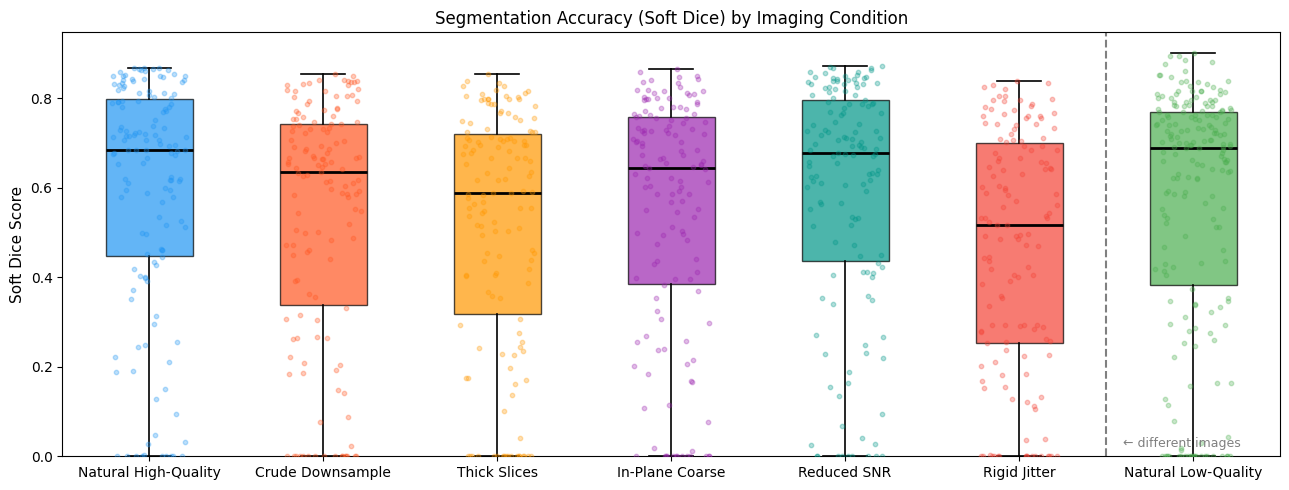

In [22]:
VARIANT_LABELS = {
    "hires":             "Natural High-Quality",
    "crude_downsample":  "Crude Downsample",
    "thick_slice":       "Thick Slices",
    "inplane_coarsening":"In-Plane Coarse",
    "reduced_snr":       "Reduced SNR",
    "rigid_jitter":      "Rigid Jitter",
    "lower_resolution":  "Natural Low-Quality",
}
VARIANT_COLORS = {
    "hires":             "#2196F3",
    "crude_downsample":  "#FF5722",
    "thick_slice":       "#FF9800",
    "inplane_coarsening":"#9C27B0",
    "reduced_snr":       "#009688",
    "rigid_jitter":      "#F44336",
    "lower_resolution":  "#4CAF50",
}
SAVE_DIR = Path(RUN_DIR)
fig, ax = plt.subplots(figsize=(13, 5))
variant_order = DEGRADED_VARIANTS + HOLDOUT_VARIANTS
dice_arrays = [
    train_df[train_df["variant"] == v]["soft_dice"].dropna().values
    for v in DEGRADED_VARIANTS
] + [holdout_df["soft_dice"].dropna().values]

bp = ax.boxplot(dice_arrays, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2))
for patch, v in zip(bp["boxes"], variant_order):
    patch.set_facecolor(VARIANT_COLORS.get(v, "#aaa"))
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for j, (arr, v) in enumerate(zip(dice_arrays, variant_order)):
    jx = rng.uniform(j + 0.78, j + 1.22, size=len(arr))
    ax.scatter(jx, arr, alpha=0.3, s=10, color=VARIANT_COLORS.get(v, "#aaa"), zorder=3)

ax.set_xticks(range(1, len(variant_order) + 1))
ax.set_xticklabels([VARIANT_LABELS.get(v, v) for v in variant_order], fontsize=10)
ax.set_ylabel("Soft Dice Score", fontsize=11)
ax.set_title("Segmentation Accuracy (Soft Dice) by Imaging Condition", fontsize=12)
ax.axvline(len(DEGRADED_VARIANTS) + 0.5, color="gray", linestyle="--", lw=1.5)
ax.text(len(DEGRADED_VARIANTS) + 0.6, 0.02, "← different images", fontsize=9, color="gray")
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(SAVE_DIR / "fig1_dice_by_variant.png", dpi=150, bbox_inches="tight")
plt.show()


**§ 14 — Figure 2: All Three Image Quality Metrics vs Dice Score.**
Each panel shows one quality metric on the x-axis against soft Dice on the y-axis.
Each dot is one subject under one imaging condition, coloured by variant.
The black line is an overall linear trend fitted across all training variants.

- **Left (FWHM):** Full Width at Half Maximum — measures how blurry the image is in mm.
  A higher number means more blur. You expect Dice to *decrease* as FWHM increases.
- **Middle (HFE):** High-Frequency Energy fraction — measures how much of the image's
  spectral power is in high frequencies. In degraded images, high HFE often reflects
  aliasing and ringing artifacts rather than true sharpness, which is why the trend
  can be counter-intuitive.
- **Right (LapVar):** Laplacian Variance — measures the strength of edges in the image.
  A higher number means sharper, more detailed edges. You expect Dice to *increase* as LapVar increases.

The wide scatter within each panel reflects the 86% between-subject variance (ICC):
the same quality value produces very different Dice scores depending on the patient's lesion.


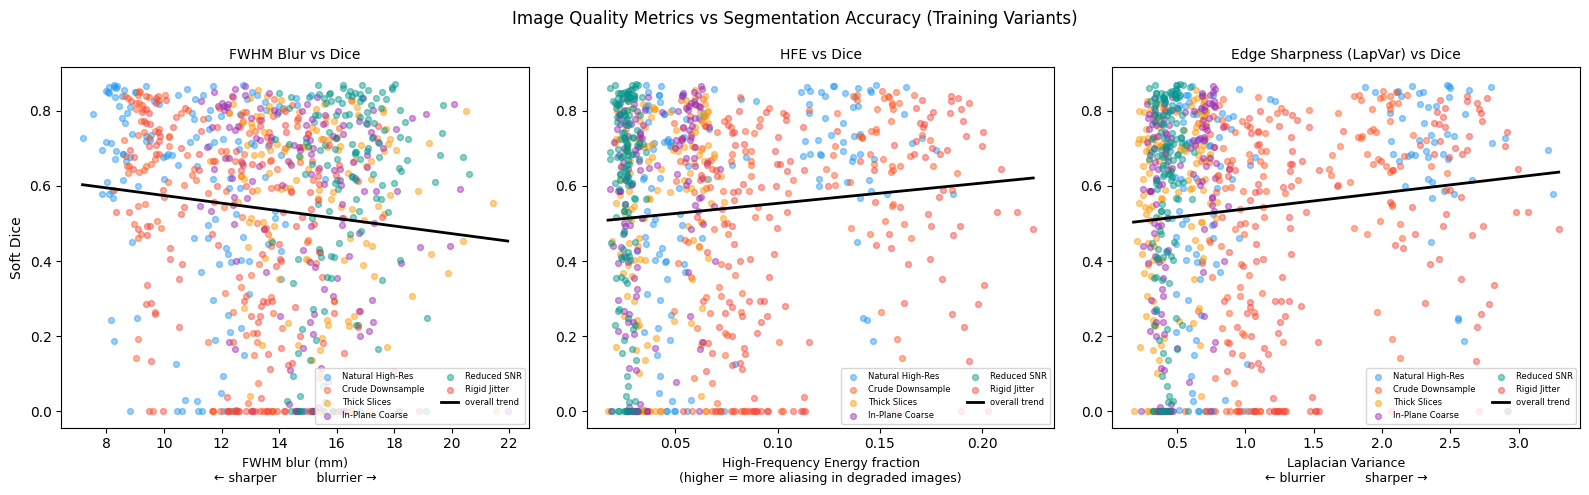

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Image Quality Metrics vs Segmentation Accuracy (Training Variants)", fontsize=12)

metrics = [
    ("mf_fwhm_mm",        "FWHM blur (mm)\n← sharper          blurrier →",  "FWHM Blur vs Dice"),
    ("mf_hi_freq_energy",  "High-Frequency Energy fraction\n(higher = more aliasing in degraded images)",
                                                                               "HFE vs Dice"),
    ("mf_lap_var",         "Laplacian Variance\n← blurrier          sharper →","Edge Sharpness (LapVar) vs Dice"),
]

for ax, (col, xlabel, title) in zip(axes, metrics):
    for v in DEGRADED_VARIANTS:
        sub = train_df[train_df["variant"] == v].dropna(subset=[col, "soft_dice"])
        ax.scatter(sub[col], sub["soft_dice"],
                   color=VARIANT_COLORS.get(v, "#aaa"), alpha=0.45, s=18,
                   label=VARIANT_LABELS.get(v, v))
    # Overall trend line
    xy = train_df[[col, "soft_dice"]].dropna()
    if len(xy) > 2:
        fit = np.polyfit(xy[col], xy["soft_dice"], 1)
        xs = np.linspace(xy[col].min(), xy[col].max(), 100)
        ax.plot(xs, np.polyval(fit, xs), "k-", lw=2, label="overall trend")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Soft Dice" if ax == axes[0] else "", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig2_quality_vs_dice.png", dpi=150, bbox_inches="tight")
plt.show()


**§ 15 — Figure 3: Model Coefficient Forest Plot.**
A forest plot is the standard way to display regression results visually.
Each row is one predictor. The bar is the estimated coefficient (β); the horizontal error bar is the 95% confidence interval.

- **Entirely left of zero (red)** → predictor significantly *decreases* Dice
- **Entirely right of zero (blue)** → predictor significantly *increases* Dice
- **Crosses zero (grey)** → effect is not statistically significant (p ≥ 0.05)

All predictors are z-scored so bars are directly comparable in size — a longer bar means a stronger effect.
Significance stars: *** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant.
Coefficients are on the logit(Dice) scale; roughly multiply by 0.2 to get approximate Dice-point change at median Dice.


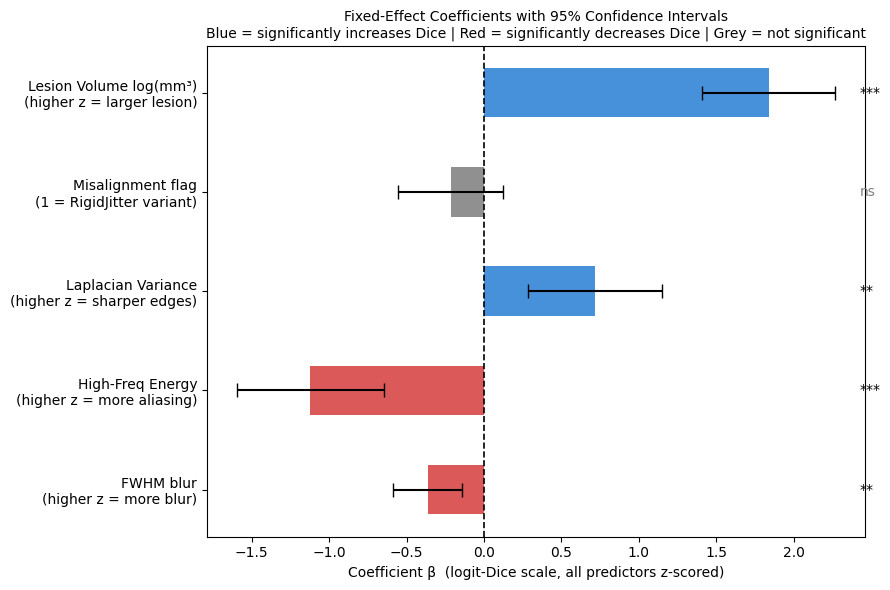

In [15]:
TERM_LABELS = {
    "z_mf_fwhm_mm":        "FWHM blur\n(higher z = more blur)",
    "z_mf_hi_freq_energy":  "High-Freq Energy\n(higher z = more aliasing)",
    "z_mf_lap_var":         "Laplacian Variance\n(higher z = sharper edges)",
    "misalign":             "Misalignment flag\n(1 = RigidJitter variant)",
    "z_log_lesion_mm3":      "Lesion Volume log(mm³)\n(higher z = larger lesion)",
}

# Align coef and CI on the same index — drop Intercept from both before converting to arrays
fe_all = mixed_result.fe_params
ci_all = mixed_result.conf_int()
ci_all.columns = ["lo", "hi"]
terms  = [t for t in fe_all.index if t != "Intercept"]
coefs  = fe_all.loc[terms].values
lo     = ci_all.loc[terms, "lo"].values
hi     = ci_all.loc[terms, "hi"].values
err_lo = coefs - lo
err_hi = hi - coefs

colors = ["#d32f2f" if h < 0 else "#1976d2" if l > 0 else "#757575"
          for l, h in zip(lo, hi)]
labels = [TERM_LABELS.get(t, t) for t in terms]

fig, ax = plt.subplots(figsize=(9, max(4, len(terms) * 1.2)))
y = np.arange(len(terms))
ax.barh(y, coefs, xerr=[err_lo, err_hi], color=colors, alpha=0.8,
        error_kw=dict(ecolor="black", lw=1.5, capsize=5), height=0.5)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Coefficient β  (logit-Dice scale, all predictors z-scored)", fontsize=10)
ax.set_title("Fixed-Effect Coefficients with 95% Confidence Intervals\n"
             "Blue = significantly increases Dice | Red = significantly decreases Dice | Grey = not significant",
             fontsize=10)

pvals = mixed_result.pvalues
x_star = max(hi) + abs(max(hi) - min(lo)) * 0.04
for i, t in enumerate(terms):
    p    = pvals.get(t, 1.0)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(x_star, i, star, va="center", fontsize=10,
            color="black" if star != "ns" else "gray")

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig3_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()


**§ 16 — Figure 4: Lesion Volume vs Dice Score.**
Each dot is one subject (natural high-resolution condition, one observation per subject).
The x-axis is lesion volume in millilitres (mL); the y-axis is soft Dice.
The curve is a log-linear trend (lesion volume is log-transformed before fitting because
the distribution is highly right-skewed — most lesions are small, a few are very large).

This plot directly visualises *why* the ICC is 0.86: the spread in Dice at any given
lesion size is large, but the overall trend shows that larger lesions are generally easier
to segment (higher Dice). Tiny lesions (\< 1 mL) are often missed entirely (Dice near 0)
because there are not enough voxels to produce a reliable overlap.
This between-subject variation dominates everything else in the model.


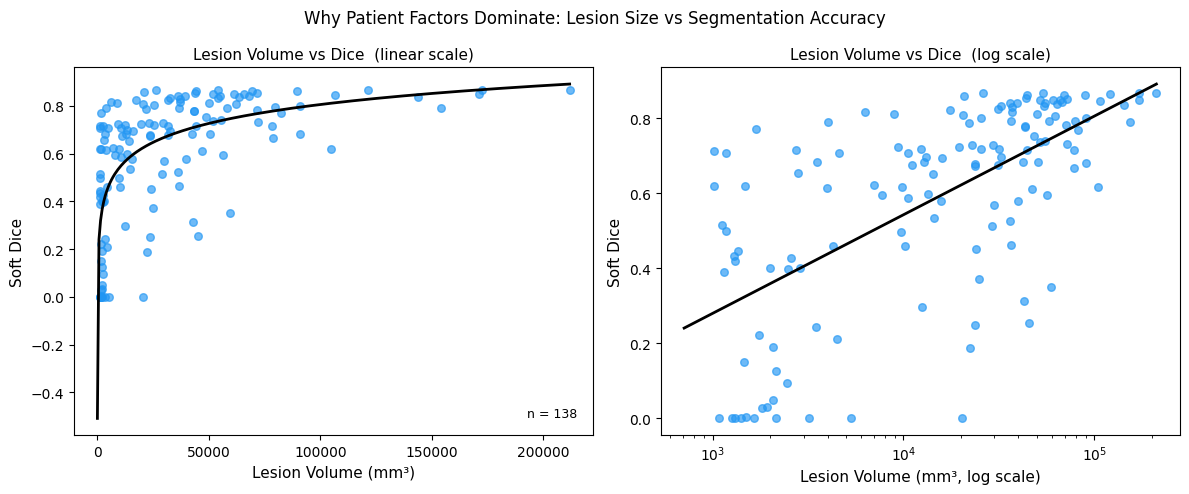

In [16]:
if "lesion_mm3" in train_df.columns and train_df["lesion_mm3"].notna().sum() > 10:
    subj = train_df[train_df["variant"] == "hires"][["key","lesion_mm3","soft_dice"]].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Linear x-axis
    ax = axes[0]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    x, y = subj["lesion_mm3"].values, subj["soft_dice"].values
    fit = np.polyfit(np.log1p(x), y, 1)
    xs = np.linspace(0, x.max(), 300)
    ax.plot(xs, np.polyval(fit, np.log1p(xs)), "k-", lw=2)
    ax.set_xlabel("Lesion Volume (mm³)", fontsize=11)
    ax.set_ylabel("Soft Dice", fontsize=11)
    ax.set_title("Lesion Volume vs Dice  (linear scale)", fontsize=11)
    ax.text(0.97, 0.05, f"n = {len(subj)}", ha="right", transform=ax.transAxes, fontsize=9)

    # Log x-axis (easier to read for skewed data)
    ax = axes[1]
    ax.scatter(subj["lesion_mm3"], subj["soft_dice"], alpha=0.65, s=30, color="#2196F3")
    ax.plot(xs[xs > 0], np.polyval(fit, np.log1p(xs[xs > 0])), "k-", lw=2)
    ax.set_xscale("log")
    ax.set_xlabel("Lesion Volume (mm³, log scale)", fontsize=11)
    ax.set_ylabel("Soft Dice", fontsize=11)
    ax.set_title("Lesion Volume vs Dice  (log scale)", fontsize=11)

    plt.suptitle("Why Patient Factors Dominate: Lesion Size vs Segmentation Accuracy", fontsize=12)
    plt.tight_layout()
    plt.savefig(SAVE_DIR / "fig4_lesion_size_vs_dice.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Lesion size data not available — skipping Figure 4.")


**§ 17 — Figure 5: Holdout Calibration Plot.**
"Holdout" means a set of subjects the model never saw during training — here, 198 subjects
with naturally low-resolution images. "Calibration" means: do the model's predicted Dice
scores match the actual Dice scores?

The x-axis is what the model predicted; the y-axis is what actually happened.
- The **dashed black line** is perfect calibration: predicted = observed.
- The **orange line** is where the predictions actually land.
- If the orange line is *above* the dashed line, the model under-predicts (predicts too low).
- If *below*, it over-predicts.

The systematic gap here (orange line above dashed) shows the model under-predicts by about
0.15 Dice points for natural low-res images. This makes sense: the model was trained on
*synthetically* degraded images which tend to be harder than naturally degraded ones.
The Pearson r = 0.60 shows the *ranking* is still reasonable — it just needs a calibration shift.

The right panel shows the distribution of residuals (observed − predicted). A perfectly
calibrated model would be centred at 0. The rightward shift here confirms the under-prediction.


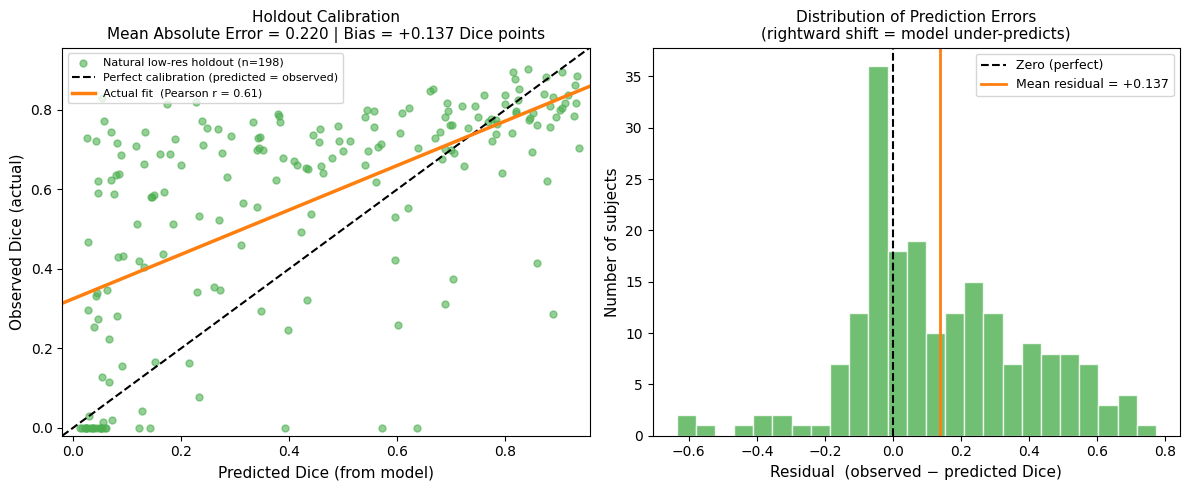

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(pred, obs, alpha=0.6, s=25, color="#4CAF50",
           label=f"Natural low-res holdout (n={len(obs)})")
lo_line = min(pred.min(), obs.min()) - 0.02
hi_line = max(pred.max(), obs.max()) + 0.02
line = np.linspace(lo_line, hi_line, 100)
ax.plot(line, line, "k--", lw=1.5, label="Perfect calibration (predicted = observed)")
fit = np.polyfit(pred, obs, 1)
ax.plot(line, np.polyval(fit, line), color="tab:orange", lw=2.5,
        label=f"Actual fit  (Pearson r = {corr:.2f})")
ax.set_xlabel("Predicted Dice (from model)", fontsize=11)
ax.set_ylabel("Observed Dice (actual)", fontsize=11)
ax.set_title(f"Holdout Calibration\nMean Absolute Error = {mae:.3f} | Bias = {bias:+.3f} Dice points", fontsize=11)
ax.legend(fontsize=8)
ax.set_xlim(lo_line, hi_line); ax.set_ylim(lo_line, hi_line)

ax = axes[1]
residuals = obs - pred
ax.hist(residuals, bins=25, color="#4CAF50", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1.5, label="Zero (perfect)")
ax.axvline(float(np.mean(residuals)), color="tab:orange", lw=2,
           label=f"Mean residual = {np.mean(residuals):+.3f}")
ax.set_xlabel("Residual  (observed − predicted Dice)", fontsize=11)
ax.set_ylabel("Number of subjects", fontsize=11)
ax.set_title("Distribution of Prediction Errors\n(rightward shift = model under-predicts)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig5_holdout_calibration.png", dpi=150, bbox_inches="tight")
plt.show()


**§ 18 — Figure 6: Variance Decomposition (ICC).**
The Intraclass Correlation Coefficient (ICC) answers the question:
*"Of all the variation in Dice scores, how much comes from patient differences vs
image quality differences?"*

**How it is calculated:**
The mixed-effects model separates variance into two components:
1. **Group (between-subject) variance** — how much subjects differ from each other
   in baseline Dice, regardless of image quality. Captured by the random intercept per subject.
2. **Residual variance** — remaining variation within each subject across imaging conditions,
   plus measurement noise.

ICC = Group Variance / (Group Variance + Residual Variance)

If ICC = 0.86, then 86% of the total Dice variance is explained by *who the patient is*
(their lesion size, shape, location, and complexity). Only 14% is explained by image quality
plus any remaining noise. This is the key finding: patient-level factors dominate,
but image quality still has a real, statistically significant effect on top of that.


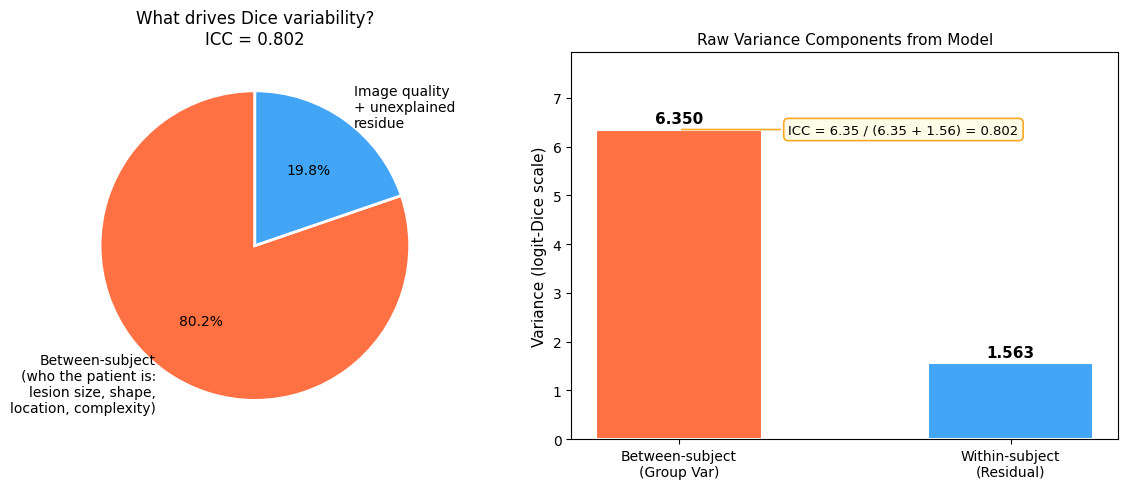


ICC = 0.802  (80.2% of Dice variance is between-subject)
Group variance: 6.350  |  Residual: 1.563


In [18]:
group_var = float(mixed_result.cov_re.iloc[0, 0]) if hasattr(mixed_result, "cov_re") else 9.704
resid_var = float(mixed_result.scale)
icc = group_var / (group_var + resid_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: pie ─────────────────────────────────────────────────────────────────
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    [icc, 1 - icc],
    labels=["Between-subject\n(who the patient is:\nlesion size, shape,\nlocation, complexity)",
            "Image quality\n+ unexplained\nresidue"],
    colors=["#FF7043", "#42A5F5"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title(f"What drives Dice variability?\nICC = {icc:.3f}", fontsize=12)

# ── Right: bar ────────────────────────────────────────────────────────────────
ax = axes[1]
bar_vals = [group_var, resid_var]
bar_labels = ["Between-subject\n(Group Var)", "Within-subject\n(Residual)"]
bars = ax.bar(bar_labels, bar_vals,
              color=["#FF7043", "#42A5F5"],
              edgecolor="white", linewidth=1.5, width=0.5)

# Value labels flush with bar tops
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ax.get_ylim()[1] * 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# ICC formula annotation: pinned just to the right of the tallest bar's top
tall_bar = bars[0]
ax.annotate(
    f"ICC = {group_var:.2f} / ({group_var:.2f} + {resid_var:.2f}) = {icc:.3f}",
    xy=(tall_bar.get_x() + tall_bar.get_width() / 2, group_var),
    xytext=(tall_bar.get_x() + tall_bar.get_width() + 0.08, group_var),
    va="center", ha="left", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fffde7", edgecolor="#f9a825", linewidth=1.2),
    arrowprops=dict(arrowstyle="-", color="#f9a825", lw=1.2),
)

# Add a little top margin so labels aren't clipped
ax.set_ylim(0, max(bar_vals) * 1.25)
ax.set_ylabel("Variance (logit-Dice scale)", fontsize=11)
ax.set_title("Raw Variance Components from Model", fontsize=11)

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig6_icc_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nICC = {icc:.3f}  ({icc*100:.1f}% of Dice variance is between-subject)")
print(f"Group variance: {group_var:.3f}  |  Residual: {resid_var:.3f}")


**§ 19 — Figure 7: Per-variant Summary Statistics Table.**
A concise table of the key numbers a reviewer will look for: how many subjects, mean and standard deviation of hard Dice, detection rate (fraction of subjects where the model found *any* lesion, i.e. Dice > 0), and mean lesion volume. This is the standard results table format for lesion segmentation papers.


In [19]:
VARIANT_ORDER = DEGRADED_VARIANTS + HOLDOUT_VARIANTS
VARIANT_LABEL_MAP = {
    "hires":             "Natural High-Res",
    "crude_downsample":  "Crude Downsample",
    "thick_slice":       "Thick Slices",
    "inplane_coarsening":"In-Plane Coarse",
    "reduced_snr":       "Reduced SNR",
    "rigid_jitter":      "Rigid Jitter",
    "lower_resolution":  "Natural Low-Res (holdout)",
}

rows = []
for v in VARIANT_ORDER:
    sub = all_df[all_df["variant"] == v]
    n   = len(sub)
    if n == 0:
        continue

    dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in sub.columns else "soft_dice"
    dice     = sub[dice_col].dropna()
    detected = (dice > 0).sum()

    les_col  = "lesion_mm3" if "lesion_mm3" in sub.columns else None

    rows.append({
        "Variant":              VARIANT_LABEL_MAP.get(v, v),
        "Role":                 "Holdout" if v in HOLDOUT_VARIANTS else "Training",
        "N subjects":           n,
        "Mean Dice ± SD":       f"{dice.mean():.3f} ± {dice.std():.3f}",
        "Median Dice":          f"{dice.median():.3f}",
        "Detection rate":       f"{detected}/{n} ({100*detected/n:.0f}%)",
        "Mean lesion (mm³)":    f"{sub[les_col].mean():.0f}" if les_col else "—",
    })

summary_table = pd.DataFrame(rows).set_index("Variant")
print("Per-variant segmentation performance summary\n")
summary_table


Per-variant segmentation performance summary



,Role,N subjects,Mean Dice ± SD,Median Dice,Detection rate,Mean lesion (mm³)
Variant,,,,,,
Natural High-Res,Training,138,0.589 ± 0.266,0.685,129/138 (93%),33696
Crude Downsample,Training,138,0.532 ± 0.274,0.636,122/138 (88%),33696
Thick Slices,Training,138,0.510 ± 0.272,0.589,120/138 (87%),33696
In-Plane Coarse,Training,138,0.545 ± 0.270,0.645,125/138 (91%),33696
Reduced SNR,Training,138,0.588 ± 0.264,0.678,129/138 (93%),33696
Rigid Jitter,Training,138,0.460 ± 0.270,0.517,122/138 (88%),33696
Natural Low-Res (holdout),Holdout,198,0.562 ± 0.280,0.690,176/198 (89%),26848


**§ 20 — Figure 8: Detection Rate and Dice-Among-Detected.**
Reporting overall mean Dice conflates two different failure modes: (1) the model completely misses a lesion (Dice = 0, a *detection* failure) and (2) the model finds something but the overlap is imperfect (a *segmentation quality* failure). Separating these gives a clearer picture. The left panel shows what fraction of subjects had any lesion detected (Dice > 0) per variant. The right panel shows mean Dice restricted to detected subjects only, removing the floor effect from missed lesions.


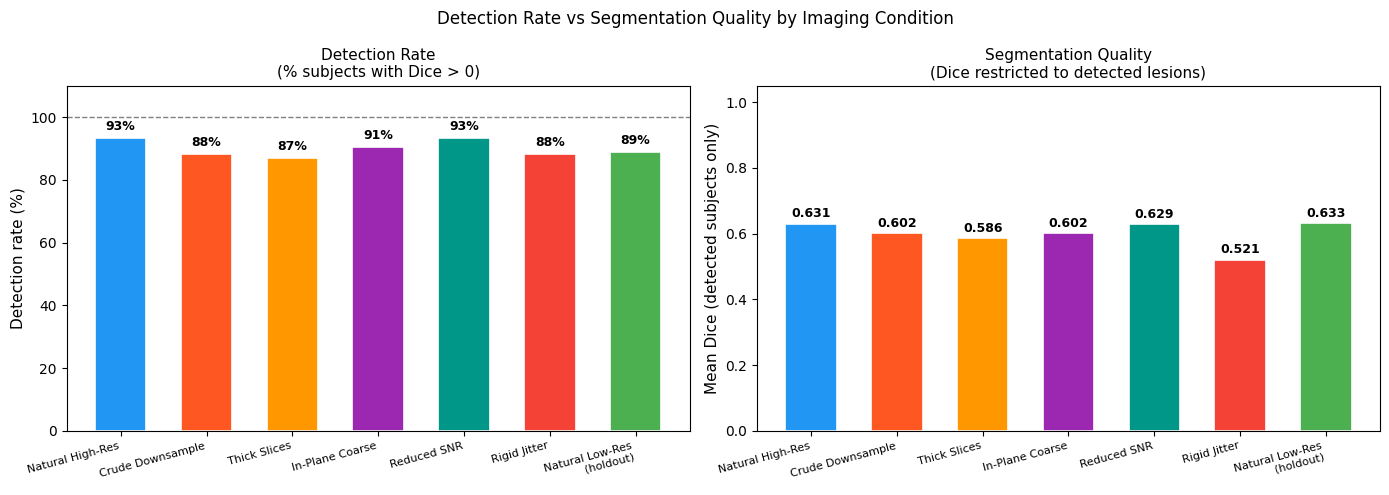

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Detection Rate vs Segmentation Quality by Imaging Condition", fontsize=12)

det_rates, dice_detected, labels_plot, colors_plot = [], [], [], []
dice_col = "hard_dice_at_0.50" if "hard_dice_at_0.50" in all_df.columns else "soft_dice"

for v in VARIANT_ORDER:
    sub  = all_df[all_df["variant"] == v]
    dice = sub[dice_col].dropna()
    if len(dice) == 0:
        continue
    det_rates.append(100 * (dice > 0).mean())
    dice_detected.append(dice[dice > 0].mean())
    labels_plot.append(VARIANT_LABEL_MAP.get(v, v).replace(" (holdout)", "\n(holdout)"))
    colors_plot.append(VARIANT_COLORS.get(v, "#aaa"))

x = np.arange(len(labels_plot))
bar_kw = dict(edgecolor="white", linewidth=1.2, width=0.6)

# Detection rate
ax = axes[0]
bars = ax.bar(x, det_rates, color=colors_plot, **bar_kw)
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=8, rotation=15, ha="right")
ax.set_ylabel("Detection rate (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("Detection Rate\n(% subjects with Dice > 0)", fontsize=11)
ax.axhline(100, color="gray", linestyle="--", lw=1)
for bar, val in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Dice among detected
ax = axes[1]
bars = ax.bar(x, dice_detected, color=colors_plot, **bar_kw)
ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=8, rotation=15, ha="right")
ax.set_ylabel("Mean Dice (detected subjects only)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Segmentation Quality\n(Dice restricted to detected lesions)", fontsize=11)
for bar, val in zip(bars, dice_detected):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(SAVE_DIR / "fig8_detection_vs_quality.png", dpi=150, bbox_inches="tight")
plt.show()


**§ 14 — Non-linear sensitivity analysis (cubic B-spline OLS).** Fits an ordinary-least-squares model with four-degree-of-freedom natural cubic B-spline basis expansions for each quality metric, with cluster-robust standard errors grouped by subject. This non-parametric alternative relaxes the linearity assumption of the primary LME and serves as a sensitivity check: close agreement between the spline and linear holdout metrics supports the adequacy of the linear specification; substantial divergence suggests non-linear quality–accuracy relationships that may warrant further investigation.

In [21]:
# Optional non-linear sensitivity model (GAM-like with cubic B-splines + clustered SEs)
if not active_predictors:
    print("No varying quality predictors available; skipping spline model.")
else:
    spline_terms = [f"bs({col}, df=4, degree=3, include_intercept=False)" for col in active_predictors]
    spline_formula = "1 + " + " + ".join(spline_terms)

    X_train = dmatrix(spline_formula, train_df, return_type="dataframe")
    if train_df["misalign"].nunique() > 1:
        X_train["misalign"] = train_df["misalign"].values

    spline_result = sm.OLS(train_df["logit_dice"], X_train).fit(
        cov_type="cluster",
        cov_kwds={"groups": train_df[GROUP_COL]},
    )

    print(spline_result.summary().tables[0])

    # Holdout prediction for comparison.
    # Clip to training bounds to avoid spline basis extrapolation errors.
    holdout_for_spline = holdout_df.copy()
    for col in active_predictors:
        lo = float(train_df[col].min())
        hi = float(train_df[col].max())
        holdout_for_spline[col] = holdout_for_spline[col].clip(lo, hi)

    X_holdout = dmatrix(X_train.design_info, holdout_for_spline, return_type="dataframe")
    for col in X_train.columns:
        if col not in X_holdout.columns:
            X_holdout[col] = 0.0
    X_holdout = X_holdout[X_train.columns]

    holdout_df["pred_logit_spline"] = spline_result.predict(X_holdout)
    holdout_df["pred_soft_dice_spline"] = expit(holdout_df["pred_logit_spline"])

    obs = holdout_df[OUTCOME].to_numpy(dtype=float)
    pred_spline = holdout_df["pred_soft_dice_spline"].to_numpy(dtype=float)
    res_spline = obs - pred_spline

    spline_metrics = pd.Series(
        {
            "mae_spline": float(np.mean(np.abs(res_spline))),
            "rmse_spline": float(np.sqrt(np.mean(res_spline ** 2))),
            "bias_spline": float(np.mean(res_spline)),
            "pearson_r_spline": float(np.corrcoef(obs, pred_spline)[0, 1]),
        }
    )
    print(spline_metrics.to_string())


                            OLS Regression Results                            
Dep. Variable:             logit_dice   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     5.701
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.81e-08
Time:                        14:54:01   Log-Likelihood:                -2150.8
No. Observations:                 828   AIC:                             4330.
Df Residuals:                     814   BIC:                             4396.
Df Model:                          13                                         
Covariance Type:              cluster                                         
mae_spline          0.384342
rmse_spline         0.430248
bias_spline         0.309061
pearson_r_spline    0.062286


## Interpretation Checklist

- Check whether quality predictors actually vary by degradation (see the within-key spread table).
- If predictors do not vary across cohorts, the model can only learn subject-level associations, not degradation penalties.
- Use the holdout calibration bias (`observed - predicted`) to quantify any additional natural low-res penalty.
- If needed, recompute quality metrics directly on degraded images before final manuscript-level inference.
